# Inferencia estadística vs Aprendizaje de máquinas

Pía Amigo, 2026

### Parte 1: Ajuste de recta

(Adaptado de Viviana Acquaviva (2023))

**Objetivo:** Resolver el mismo problema con dos estrategias distintas y comparar sus resultados.

**Nombre(s):**

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Parámetros para figuras de alta calidad
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

np.random.seed(16)  # semilla fija para reproducibilidad

x = np.arange(10)
y = 2*x + 5 + np.random.randn(10)  # datos con scatter gaussiano
y = np.round(y, 1)

Los datos corresponden al movimiento de un auto con rapidez constante,
donde el eje $x$ es tiempo (en segundos) y el eje $y$ es distancia (en metros).

**Pregunta:** A partir de estos datos queremos predecir $d(t=12\text{ s})$.
Antes de escribir código: ¿cómo resolverías este problema? Describe tu estrategia con palabras.

**Tu respuesta:**

Yo se que el modelo debe ser lineal, debe verse como una linea recta, asi que debo buscar los valores para la pendiente y la velocidad que mejor se ajusten y evaluar en 12 segundos

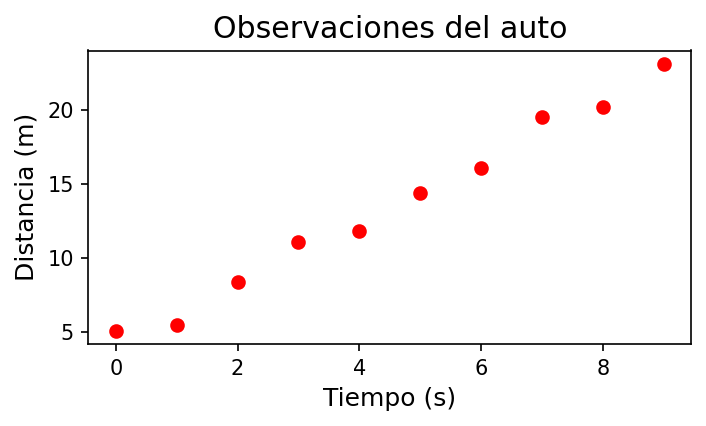

In [3]:
# Visualiza los datos
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Observaciones del auto')
plt.tight_layout()

## Parte 1: Inferencia estadística

Sabemos que la relación entre distancia y tiempo para un auto con rapidez constante es:
$$d = d_0 + v \cdot t$$

Este modelo tiene dos parámetros: $d_0$ (posición inicial) y $v$ (velocidad).
Nuestro objetivo es **encontrar los valores de $d_0$ y $v$** que mejor explican los datos.

### 1a. Búsqueda por grilla

Una estrategia es probar muchas combinaciones de parámetros y quedarse con la que
minimiza el **error cuadrático medio (MSE) (Mínimos cuadrados)**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2$$

In [4]:
# Definimos la grilla de parámetros a explorar
m_range = np.linspace(0, 5, 100)   # posibles velocidades
b_range = np.linspace(0, 10, 100)  # posibles posiciones iniciales

best_mse = np.inf
bestm, bestb = 0, 0

# Completa el loop: para cada combinación (m, b),
# calcula el MSE y guarda los mejores parámetros
for m in m_range:
    for b in b_range:
        # Tu código acá:
        y_pred = m * x + b
        mse = np.mean((y - y_pred)**2)
        if mse < best_mse:
            best_mse = mse
            bestm = m
            bestb = b
print(f'Mejor pendiente (velocidad):     {bestm:.3f} m/s')
print(f'Mejor intercepto (pos. inicial): {bestb:.3f} m')
print(f'MSE mínimo: {best_mse:.4f}')

Mejor pendiente (velocidad):     2.071 m/s
Mejor intercepto (pos. inicial): 4.242 m
MSE mínimo: 0.3699


<details>
<summary>Ayuda</summary>

Dentro del loop calcula la predicción y el MSE:
```python
y_pred = m * x + b
mse = np.mean((y - y_pred)**2)
```
Luego comparas con `best_mse` y actualizas si encontraste algo mejor.
</details>

**¿Cuáles son los valores encontrados? ¿Son razonables físicamente?**
Con este modelo, ¿cuánto vale $d(t=12\text{ s})$?

- `bestm` = 2.071
- `bestb` = 4.242
- $d(t=12)$ = 4.242+2.071*12 

Si son razonables fisicamente

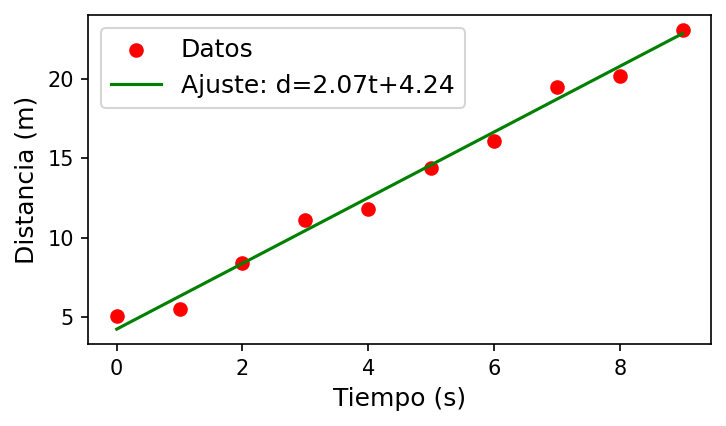

In [5]:
# Grafica los datos y la recta con los mejores parámetros
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red', label='Datos')
plt.plot(x, bestm*x + bestb, c='g', label=f'Ajuste: d={bestm:.2f}t+{bestb:.2f}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

### 1b. Ajuste con incertezas

En astronomía las mediciones siempre tienen incertezas.
Cuando las incluimos, los puntos más precisos (menor $\sigma_i$) deben tener
**más peso** en el ajuste. La función a minimizar se convierte en el $\chi^2$:

$$\chi^2 = \sum_{i=1}^{N} \frac{(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2}{\sigma_i^2}$$

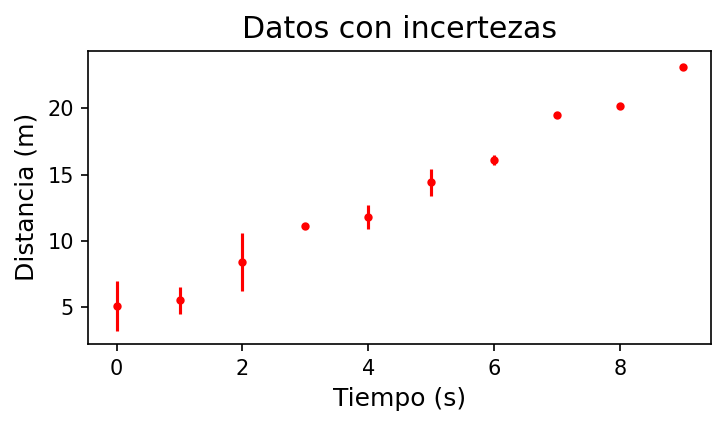

In [6]:
np.random.seed(10)
dy = np.random.randn(10) * np.sqrt(2)  # incertezas aleatorias

plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Datos con incertezas')
plt.tight_layout()

In [7]:
# Encuentra los mejores parámetros usando chi2 en lugar de MSE
best_chi2 = np.inf
bestm_werr, bestb_werr = 0, 0

for m in m_range:
    for b in b_range:
        # Tu código acá
        y_pred = m * x + b
        chi2 = np.sum(((y - y_pred) / np.abs(dy))**2)
        if chi2 < best_chi2:
            best_chi2 = chi2
            bestm_werr = m
            bestb_werr = b

print(f'Mejor pendiente (con incertezas):  {bestm_werr:.3f} m/s')
print(f'Mejor intercepto (con incertezas): {bestb_werr:.3f} m')

Mejor pendiente (con incertezas):  1.818 m/s
Mejor intercepto (con incertezas): 5.657 m


<details>
<summary> Ayuda</summary>

```python
chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
```
</details>

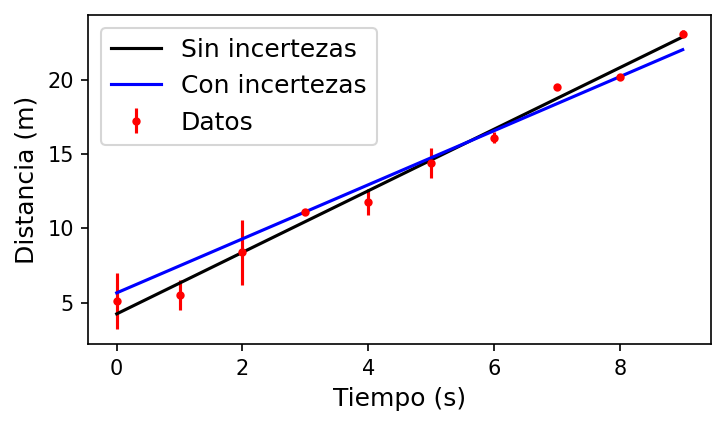

In [8]:
# Comparamos ambos ajustes
plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ', label='Datos')
plt.plot(x, bestb + bestm * x, c='black', label='Sin incertezas')
plt.plot(x, bestb_werr + bestm_werr * x, c='b', label='Con incertezas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

**Pregunta: ¿Cambiaron mucho los parámetros al incluir incertezas? ¿Tiene sentido ese cambio?**

**Tu respuesta:**

Si cambian, el ajuste presenta otra pendiente, tiene sentido pues ahora los datos con mayor incerteza pesan menos en el resultado final.


## Parte 2: Machine Learning

En ML **no asumimos la forma del modelo**. Le damos los datos a un algoritmo
y él aprende la relación entre input ($t$) y output ($d$) directamente.

Probaremos dos modelos:
- [**Regresión lineal**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) (`LinearRegression`): aprende la misma recta, pero sin que nosotros definamos el modelo físico.
- [**kNN Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) (`KNeighborsRegressor`): predice el valor de un punto nuevo como el **promedio de sus $k$ vecinos más cercanos**. No asume ninguna forma funcional.



### 2a. División train/test

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

np.random.seed(10)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=3)

print(f'Entrenamiento: {X_train} → {y_train}')
print(f'Prueba:        {X_test} → {y_test}')

Entrenamiento: [6 3 1 0 7 4 9] → [16.1 11.1  5.5  5.1 19.5 11.8 23.1]
Prueba:        [8 2 5] → [20.2  8.4 14.4]


**Pregunta:** ¿Por qué separamos los datos en train y test?
¿Qué pasaría si evaluáramos el modelo en los mismos datos con los que lo entrenamos?

**Tu respuesta:**
No seria correcto evaluar con los mismos datos de entrenamiento, porque siempre acertaria porque ya los conoce de antes


### 2b. Entrenar y evaluar ambos modelos

In [12]:
regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=3)

# Entrenamos con los datos de train y predecimos en test
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

Real:         [20.2  8.4 14.4]
Reg. Lineal:  [20.89  8.42 14.66]
kNN (k=3):    [19.57  7.23 15.8 ]


<details>
<summary>Ayuda</summary>

El patrón de sklearn siempre es el mismo:
```python
modelo.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1))
```
</details>

In [14]:
# Calculamos el MSE para cada modelo
mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

MSE Regresión Lineal: 0.1820
MSE kNN (k=3):        1.2407


**Pregunta: ¿Cuál modelo tiene menor MSE? Con solo 3 puntos de test, ¿qué tan confiable es esta comparación?**

**Tu respuesta:**
Regresion Lineal tiene menos MSE. Con tan pocos datos no es una comparacion confiable


### 2c. Predicción fuera del rango de entrenamiento

Ahora la pregunta original: ¿cuánto vale $d(t=12\text{ s})$?

In [13]:
t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]
pred_inf = bestm * 12 + bestb

print(f'Inferencia estadística: {pred_inf:.2f} m')
print(f'Regresión lineal (ML):  {pred_reg:.2f} m')
print(f'kNN (k=3):              {pred_knn:.2f} m')
print(f'Valor real (2*12+5):    {2*12+5:.2f} m')

Inferencia estadística: 29.09 m
Regresión lineal (ML):  29.21 m
kNN (k=3):              19.57 m
Valor real (2*12+5):    29.00 m


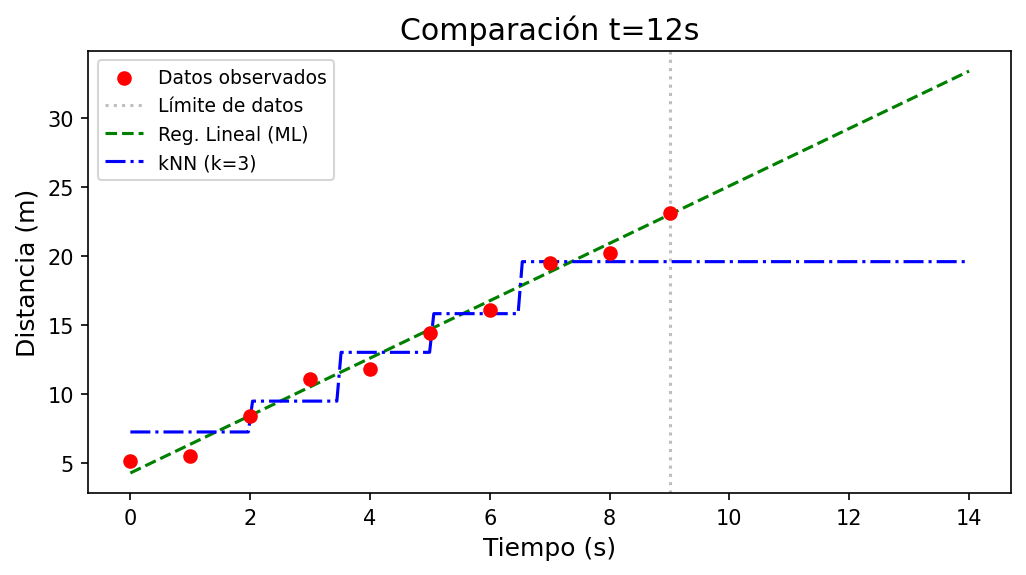

In [15]:
# Visualizamos los tres modelos en rango extendido
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='red', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='gray', linestyle=':', alpha=0.5, label='Límite de datos')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b-.', label='kNN (k=3)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=9)
plt.tight_layout()

**Pregunta: ¿Qué le pasa a kNN en la zona t > 9? ¿Por qué? ¿Es un problema para este caso?**

**Tu respuesta:**

Desde ese punto en adelante ya no puede extrapolar

### 2d. ¿Importa el valor de k?

In [ ]:
# Prueba distintos valores de k y compara el MSE en test
for k in [1, 2, 3, 5, 7]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train.reshape(-1, 1), y_train)
    mse = np.mean((y_test - m.predict(X_test.reshape(-1, 1)))**2)
    pred_12 = m.predict([[12]])[0]
    print(f'k={k}  →  MSE test: {mse:.3f}  |  d(t=12): {pred_12:.2f} m')

k=1  →  MSE test: 3.557  |  d(t=12): 23.10 m
k=2  →  MSE test: 0.474  |  d(t=12): 21.30 m
k=3  →  MSE test: 1.241  |  d(t=12): 19.57 m
k=5  →  MSE test: 7.017  |  d(t=12): 16.32 m
k=7  →  MSE test: 24.559  |  d(t=12): 13.17 m


**Pregunta: ¿Cuál k elegirías? ¿Qué criterio usarías para elegirlo de forma sistemática?**

**Tu respuesta:**

Eligiria el k=2 pues minimiza el MSE. El criterio que usaria es usar el k que minimice el error promedio


## Conclusión

Completa la siguiente tabla comparando las dos estrategias:

| | Inferencia estadística | Machine Learning |
|---|---|---|
| ¿Necesita conocer el modelo físico? | si| No|
| ¿Entrega los parámetros del modelo? | Si| Regresión lineal sí, kNN no|
| ¿Puede extrapolar fuera del rango de datos? |si el modelo usado es bueno si | Reg lineal si kNN no|
| ¿Cómo maneja las incertezas? | con chi cuadrado| no las usa |
| ¿Cuándo la usarías en tu investigación? | cuando conozco el modelo| Cuando tenngo muchos datos para entrenar |

**Pregunta final:** Si la relación fuera sinusoidal en vez de lineal (por ejemplo,
el movimiento de un péndulo), ¿qué estrategia funcionaría mejor?
Prueba cambiando `y = 2*x + 5 + ruido` por `y = np.sin(x) + ruido` al inicio.

Si fuera sinusoidal seria el mismo procedimiento, la inferencia estadistica funcionaria 